# Simulated Cancer Omics dataset using InterSim CRAN package

## Import packages and IntegrAO code

In [1]:
import numpy as np
import pandas as pd
import snf
from sklearn.cluster import spectral_clustering
from sklearn.metrics import v_measure_score
import matplotlib.pyplot as plt

import sys
import os
import argparse
import torch

import umap
from sklearn.model_selection import train_test_split

/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Add the parent directory of "integrao" to the Python path
module_path = os.path.abspath(os.path.join('../../../pan-organoid/IntegrAO/'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from integrao.dataset import GraphDataset
from integrao.main import dist2
from integrao.integrater import integrao_integrater

ModuleNotFoundError: No module named 'integrao'

## Set hyperparameters

In [3]:
torch.cuda.is_available()

False

In [4]:
# Hyperparameters
neighbor_size = 10
embedding_dims = 16
fusing_iteration = 20
normalization_factor = 1
alighment_epochs = 4000
beta = 1
mu = 0.9


dataset_name = 'pdo cancer omics'
cluster_number = 6

## Read data

In [5]:
testdata_dir = os.path.join(module_path, "data/pdo_omics_all/")

atac_ = os.path.join(testdata_dir, "atac_unsup.csv")
rna_ = os.path.join(testdata_dir, "rna_unsup.csv")
cnv_ = os.path.join(testdata_dir, "cnv_unsup.csv")
mut_ = os.path.join(testdata_dir, "mut_unsup.csv")
he_ = os.path.join(testdata_dir, "he.csv")
truelabel = os.path.join(testdata_dir, "meta00.csv")


atac = pd.read_csv(atac_, index_col=0)
rna = pd.read_csv(rna_, index_col=0)
cnv = pd.read_csv(cnv_, index_col=0)
mut = pd.read_csv(mut_, index_col=0)
he = pd.read_csv(he_, index_col=0)
truelabel = pd.read_csv(truelabel, usecols=["primary_tumor_site", "PMLB_organoidID", "doubling_rate"])

gi_sites = ["Bowel", "Esophagus/Stomach", "Pancreas"]
truelabel['cat'] = np.where(truelabel['primary_tumor_site'].isin(gi_sites), 1, 2)

# # The safer way
# site_map = {
#     'Breast': 'Breast_Ovary',
#     'Ovary/Fallopian Tube': 'Breast_Ovary'
# }

# # This only replaces the two you want to merge
# truelabel['primary_tumor_site'] = truelabel['primary_tumor_site'].replace(site_map)

# atac = np.transpose(atac)
# rna = np.transpose(rna)
# cnv = np.transpose(cnv)
# mut = np.transpose(mut)
print(atac.shape)
print(rna.shape)
print(cnv.shape)
print(mut.shape)
print(he.shape)
print(truelabel.shape)
print("finish loading data!")

(125, 1800)
(213, 1800)
(218, 405)
(226, 1800)
(65, 768)
(315, 4)
finish loading data!


In [6]:
import pandas as pd

# List of your omics dataframes and their names
omics_list = {
    "ATAC": atac,
    "RNA": rna,
    "CNV": cnv,
    "Mutation": mut,
    "HE": he
}

# Ensure the label index is ready for comparison
label_ids = set(truelabel['PMLB_organoidID'])

print(f"{'Modality':<10} | {'Total Samples':<15} | {'Missing in Labels':<20} | {'Status'}")
print("-" * 65)

for name, df in omics_list.items():
    data_ids = set(df.index)
    missing = data_ids - label_ids
    num_missing = len(missing)
    
    status = "✅ CLEAN" if num_missing == 0 else "⚠️ MISMATCH"
    
    print(f"{name:<10} | {len(data_ids):<15} | {num_missing:<20} | {status}")
    
    if num_missing > 0:
        print(f"   --> Examples missing from labels: {list(missing)[:3]}...")

Modality   | Total Samples   | Missing in Labels    | Status
-----------------------------------------------------------------
ATAC       | 125             | 0                    | ✅ CLEAN
RNA        | 213             | 0                    | ✅ CLEAN
CNV        | 218             | 0                    | ✅ CLEAN
Mutation   | 226             | 0                    | ✅ CLEAN
HE         | 65              | 0                    | ✅ CLEAN


## KNN clustering for clustering cnv, meth and mirna raw features as baseline

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import v_measure_score

# atac
kmeans = KMeans(n_clusters=cluster_number, random_state=42, n_init='auto').fit(atac.values)
labels = kmeans.labels_
aligned_truelabel = truelabel.set_index('PMLB_organoidID').reindex(atac.index)
true_labels = aligned_truelabel['primary_tumor_site'].tolist()
score = v_measure_score(true_labels, labels)
print("atac raw features kmeans clustering NMI: {}".format(score))

# rna
kmeans = KMeans(n_clusters=cluster_number, random_state=42, n_init='auto').fit(rna.values)
labels = kmeans.labels_
aligned_truelabel = truelabel.set_index('PMLB_organoidID').reindex(rna.index)
true_labels = aligned_truelabel['primary_tumor_site'].tolist()
score = v_measure_score(true_labels, labels)
print("rna raw features kmeans clustering NMI: {}".format(score))

# cnv
kmeans = KMeans(n_clusters=cluster_number, random_state=42, n_init='auto').fit(cnv.values)
labels = kmeans.labels_
aligned_truelabel = truelabel.set_index('PMLB_organoidID').reindex(cnv.index)
true_labels = aligned_truelabel['primary_tumor_site'].tolist()
score = v_measure_score(true_labels, labels)
print("cnv raw features kmeans clustering NMI: {}".format(score))

# mut
kmeans = KMeans(n_clusters=cluster_number, random_state=42, n_init='auto').fit(mut.values)
labels = kmeans.labels_
aligned_truelabel = truelabel.set_index('PMLB_organoidID').reindex(mut.index)
true_labels = aligned_truelabel['primary_tumor_site'].tolist()
score = v_measure_score(true_labels, labels)
print("mutation raw features kmeans clustering NMI: {}".format(score))

# he
kmeans = KMeans(n_clusters=cluster_number, random_state=42, n_init='auto').fit(he.values)
labels = kmeans.labels_
aligned_truelabel = truelabel.set_index('PMLB_organoidID').reindex(he.index)
true_labels = aligned_truelabel['primary_tumor_site'].tolist()
score = v_measure_score(true_labels, labels)
print("he raw features kmeans clustering NMI: {}".format(score))

atac raw features kmeans clustering NMI: 0.6452799613464695
rna raw features kmeans clustering NMI: 0.48460092277908245
cnv raw features kmeans clustering NMI: 0.19118923579060648
mutation raw features kmeans clustering NMI: 0.04194203530274431
he raw features kmeans clustering NMI: 0.22354319573199238


## IntegrAO integration

In [9]:
import torch
import numpy as np
import random

# Force reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(seed)

# Initialize integrater
integrater = integrao_integrater(
    [atac, rna, cnv, mut, he],
    dataset_name,
    neighbor_size=neighbor_size,
    embedding_dims=embedding_dims,
    fusing_iteration=fusing_iteration,
    normalization_factor=normalization_factor,
    alighment_epochs=alighment_epochs,
    beta=beta,
    mu=mu,
)
# data indexing
fused_networks = integrater.network_diffusion()
embeds_final, S_final, model = integrater.unsupervised_alignment()

labels = spectral_clustering(S_final, n_clusters=cluster_number, random_state=42)

final_sample_order = integrater.final_embeds.index.tolist()
true_labels = truelabel.set_index('PMLB_organoidID').reindex(final_sample_order)['primary_tumor_site'].tolist()

score_all = v_measure_score(true_labels, labels)
print(f"IntegrAO for clustering union {len(true_labels)} samples NMI score: ", score_all)

Start indexing input expression matrices!
Common sample between view0 and view1: 107
Common sample between view0 and view2: 98
Common sample between view0 and view3: 102
Common sample between view0 and view4: 65
Common sample between view1 and view2: 175
Common sample between view1 and view3: 176
Common sample between view1 and view4: 65
Common sample between view2 and view3: 217
Common sample between view2 and view4: 65
Common sample between view3 and view4: 65
Neighbor size: 10
Start applying diffusion!


/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/sklearn/ut

Diffusion ends! Times: 2.9465787410736084s
Starting unsupervised exmbedding extraction!
Dataset 0: (125, 1800)
Dataset 1: (213, 1800)
Dataset 2: (218, 405)
Dataset 3: (226, 1800)
Dataset 4: (65, 768)
epoch 0: loss 50.71578598022461, align_loss:2.594449
epoch 100: loss 39.375450134277344, align_loss:1.422697
epoch 200: loss 3.4178404808044434, align_loss:0.483364
epoch 300: loss 3.4083428382873535, align_loss:0.477478
epoch 400: loss 3.397162437438965, align_loss:0.469888
epoch 500: loss 3.3849644660949707, align_loss:0.461273
epoch 600: loss 3.3720157146453857, align_loss:0.452368
epoch 700: loss 3.3584084510803223, align_loss:0.443007
epoch 800: loss 3.3441410064697266, align_loss:0.433679
epoch 900: loss 3.32914137840271, align_loss:0.423951
epoch 1000: loss 3.3132822513580322, align_loss:0.414042
epoch 1100: loss 3.297003746032715, align_loss:0.404410
epoch 1200: loss 3.2800533771514893, align_loss:0.393439
epoch 1300: loss 3.2632482051849365, align_loss:0.382793
epoch 1400: loss 3.

/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [11]:
true_labels

['Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Pancreatic Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Colorectal Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Breast Cancer',
 'Ovarian Cancer',
 'Esophageal Cancer',
 'Esophageal Cancer',
 'Esophageal Cancer',
 'Esophageal Cancer',
 'E

In [10]:
labels

array([2, 3, 3, 3, 3, 3, 3, 3, 1, 5, 1, 1, 5, 5, 5, 1, 5, 5, 5, 5, 1, 1,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 5, 5, 5, 3, 3, 3, 3, 4, 3, 2,
       1, 1, 5, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2,
       0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 5, 5, 1, 1, 1, 1, 5, 1, 1, 1, 4, 1, 1, 5, 0, 2, 2, 2, 2, 2,
       1, 2, 2, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 5, 2, 1, 1, 2, 2, 2, 2,
       0, 2, 1, 2, 4, 4, 2, 2, 2, 2, 4, 1, 4, 2, 2, 1, 2, 4, 4, 0, 2, 0,
       0, 2, 4, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 0, 2, 1,
       2, 2, 1, 5, 5, 5, 1, 1, 5, 5, 5, 1, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 0, 4, 0, 2, 1,
       1, 1, 1, 1], dtype=int32)

In [17]:
aligned_true_labels = truelabel.set_index('PMLB_organoidID').reindex(final_sample_order)
aligned_true_labels['integrAO_cluster'] = labels
aligned_true_labels

,primary_tumor_site,doubling_rate,cat,integrAO_cluster
PMLB_organoidID,,,,
BPTO0051.TPO,Breast Cancer,64.00,2,2
BPTO0064.TXO,Breast Cancer,58.00,2,3
BPTO0093.TPO,Breast Cancer,NaN,2,3
BPTO0095.TPO,Breast Cancer,NaN,2,3
BPTO0143.TXO,Breast Cancer,NaN,2,3
...,...,...,...,...
SGPC0007.TXO,Pancreatic Cancer,NaN,2,1
SGPC0023.TXO,Pancreatic Cancer,27.00,2,1
SGPC0031.TXO,Pancreatic Cancer,30.00,2,1


/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Verified Embedding Shape: (268, 2)


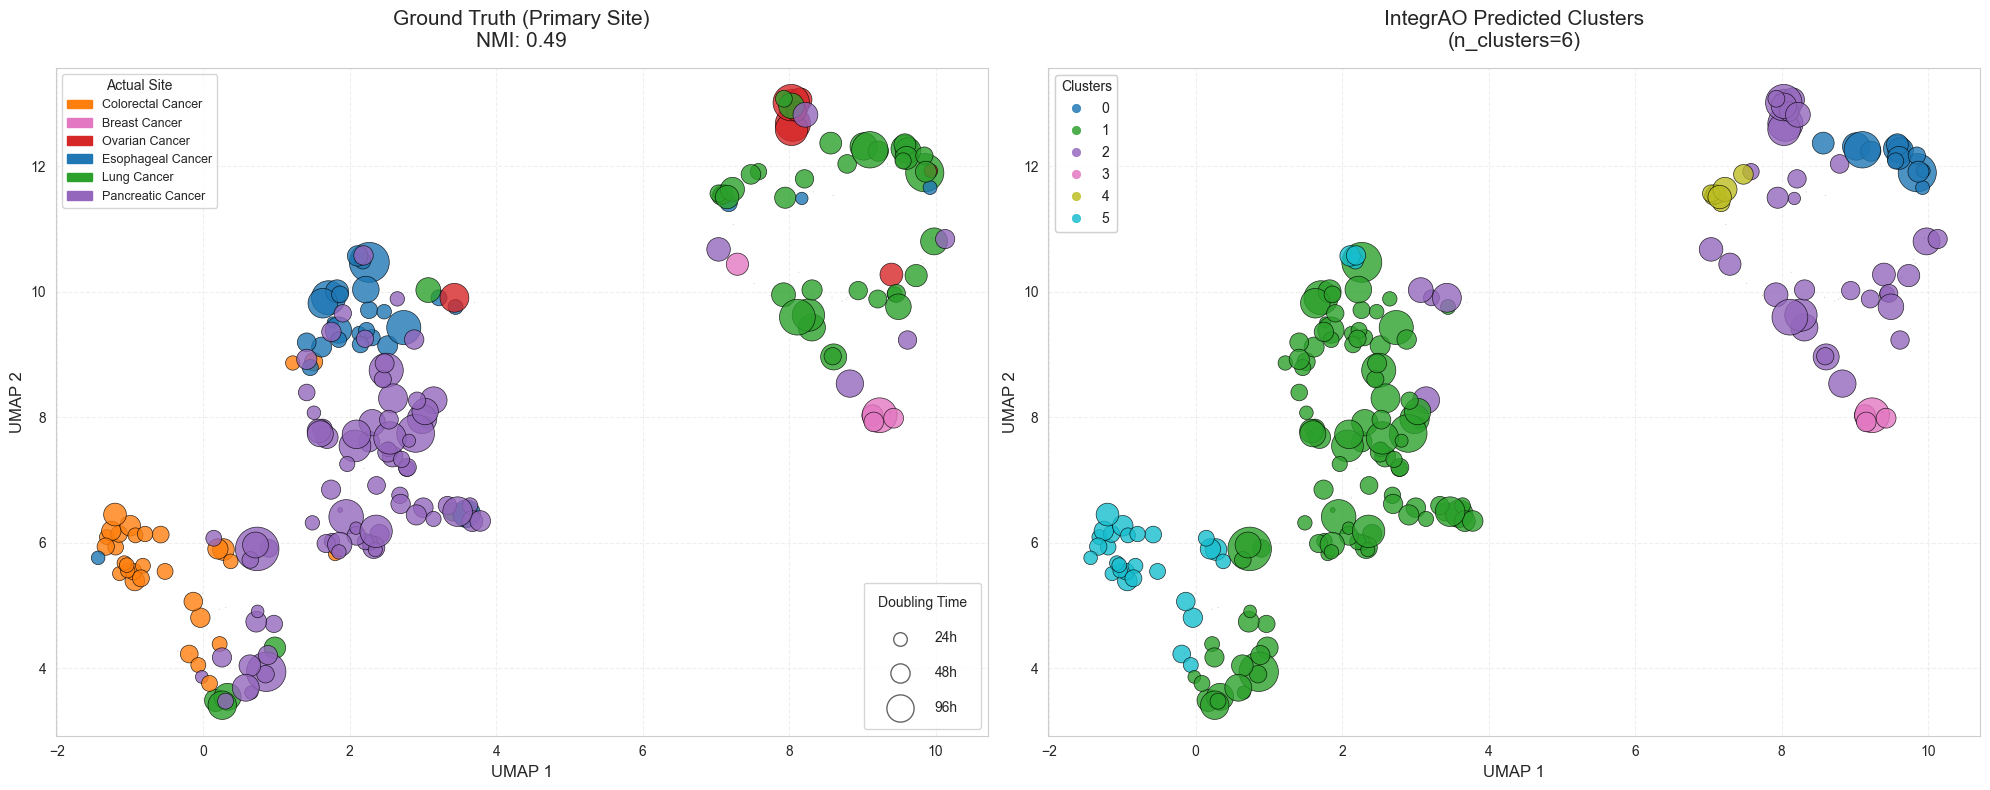

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import v_measure_score
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# --- 1. Clustering & Scoring ---
# Assuming 'embeds_final' is your IntegrAO or multi-omics fused embedding

# cluster_number = 6
# kmeans = KMeans(n_clusters=cluster_number, random_state=42, n_init='auto').fit(embeds_final.values)
# labels = kmeans.labels_
# true_labels = truelabel['primary_tumor_site'].tolist()

# Using V-Measure (NMI equivalent)
# score_all = v_measure_score(true_labels, labels)
# print(f"Clustering NMI: {score_all:.4f}")

# --- 2. UMAP Projection ---
# Using cosine metric as it often performs better on high-dim omics embeddings
reducer = umap.UMAP(n_neighbors=30, min_dist=0.11, metric='cosine', random_state=42)
embedding = reducer.fit_transform(embeds_final.values)

# --- 3. Aesthetics & Scaling ---
# Multiplying doubling_rate by a factor for visibility
# Adjust '7' if your dots are too large/small
aligned_true_labels = truelabel.set_index('PMLB_organoidID').reindex(final_sample_order)
aligned_true_labels
point_sizes = aligned_true_labels['doubling_rate'].fillna(0.01 / 7) * 4
#point_sizes = truelabel['doubling_rate'] * 7 
#point_sizes = point_sizes.tolist()

my_cancer_colors = {
    'Colorectal Cancer': '#ff7f0e',               # Orange
    'Breast Cancer': '#e377c2',              # Distinct Pink
    'Ovarian Cancer': '#d62728', # Red
    'Esophageal Cancer': '#1f77b4',    # Blue
    'Lung Cancer': '#2ca02c',                # Green
    'Pancreatic Cancer': '#9467bd'            # Purple
}

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.set_style("white")

print(f"Verified Embedding Shape: {embedding.shape}")

# Plot 1: Ground Truth (Primary Site)
point_colors_true = [my_cancer_colors.get(site, 'gray') for site in true_labels]
ax1.scatter(embedding[:, 0], embedding[:, 1], 
            c=point_colors_true, 
            s=point_sizes, 
            edgecolor='black', 
            linewidth=0.5,
            alpha=0.8)
ax1.set_title(f"Ground Truth (Primary Site)\nNMI: {score_all:.2f}", fontsize=15, pad=15)

# Plot 2: IntegrAO Predicted Clusters
scatter2 = ax2.scatter(embedding[:, 0], embedding[:, 1], 
                       c=labels, 
                       cmap='tab10', 
                       s=point_sizes, 
                       edgecolor='black', 
                       linewidth=0.5,
                       alpha=0.8)
ax2.set_title(f"IntegrAO Predicted Clusters\n(n_clusters={cluster_number})", fontsize=15, pad=15)

# --- 5. Legend Construction ---

# A. Tumor Site Legend (Colors)
site_patches = [mpatches.Patch(color=c, label=s) for s, c in my_cancer_colors.items() if s in true_labels]
site_legend = ax1.legend(handles=site_patches, title="Actual Site", 
                         loc='upper left', fontsize=9, frameon=True)
ax1.add_artist(site_legend) # Add back to ax1

# B. Doubling Time Legend (Sizes)
# Define representative rates for your data (e.g., 24h, 48h, 72h)
sample_rates = [24, 48, 96]
size_handles = [
    plt.scatter([], [], s=r*4, c='white', edgecolor='black', alpha=0.6, label=f'{r}h') 
    for r in sample_rates
]
size_legend = ax1.legend(handles=size_handles, title="Doubling Time", 
                         loc='lower right', labelspacing=1.5, borderpad=1, 
                         handletextpad=1.5, frameon=True)

# C. Cluster Legend for ax2
legend2 = ax2.legend(*scatter2.legend_elements(), title="Clusters", loc="upper left")
ax2.add_artist(legend2)

# --- 6. Final Formatting ---
for ax in [ax1, ax2]:
    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

/Users/guanqiaofeng/miniconda3/envs/integrAO/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


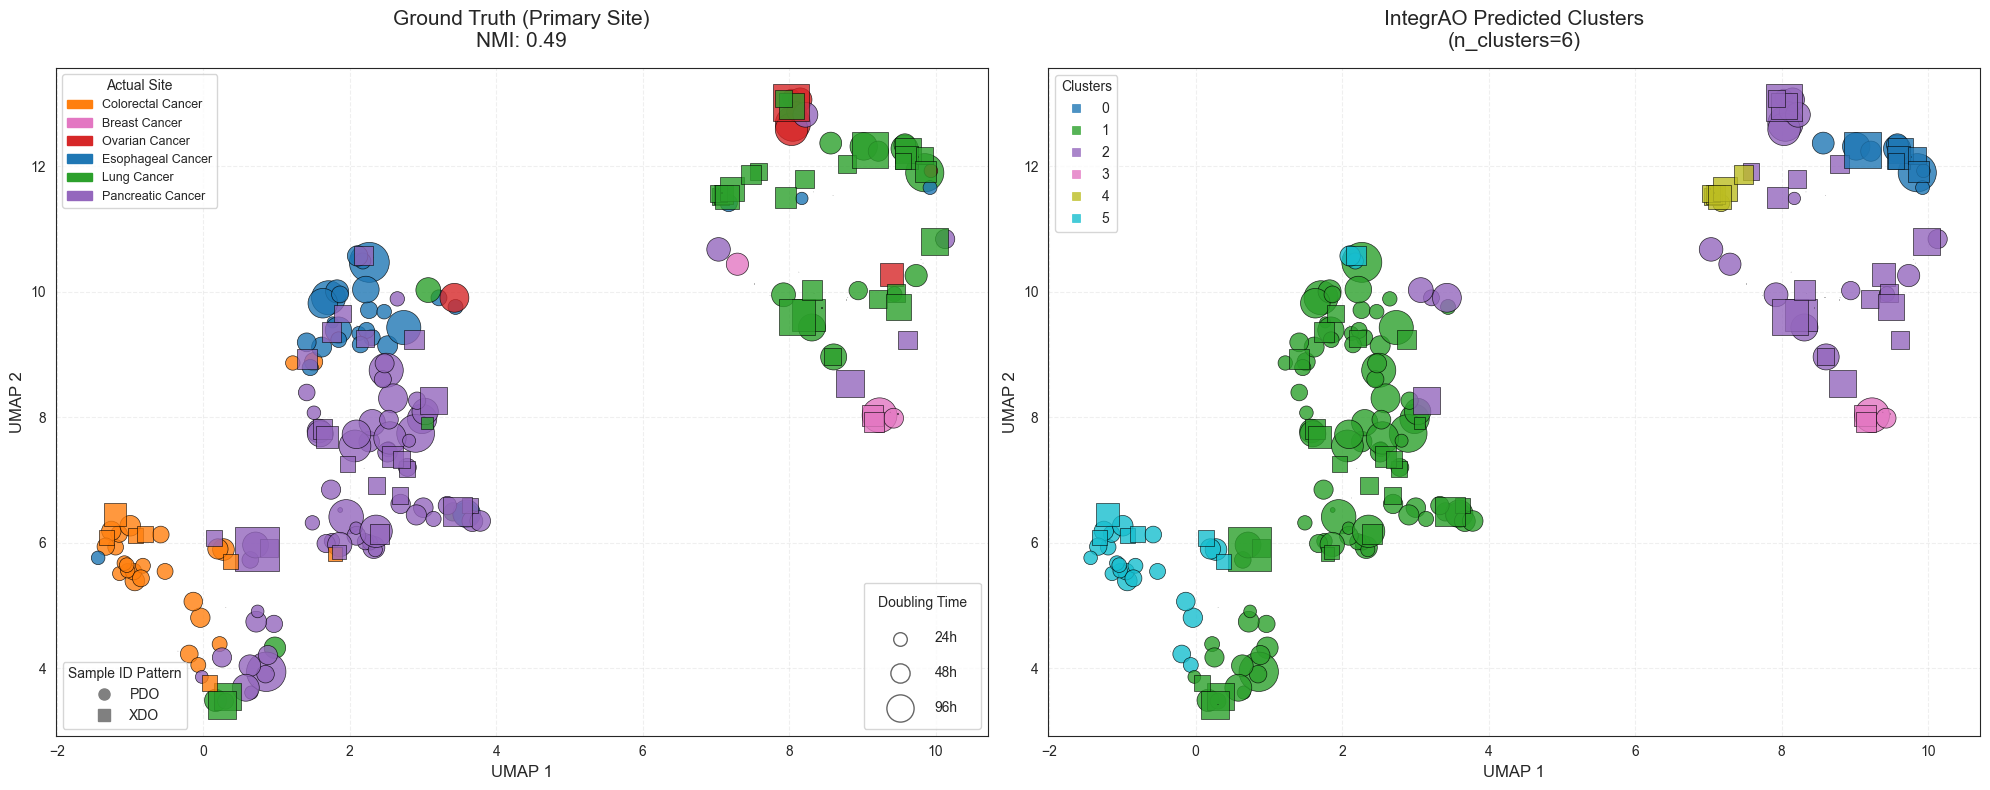

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.metrics import v_measure_score
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# --- 1. Data Prep & Label Merging ---
aligned_true_labels = truelabel.set_index('PMLB_organoidID').reindex(final_sample_order)
aligned_true_labels['integrAO_cluster'] = labels

true_labels_list = aligned_true_labels['primary_tumor_site'].tolist()
cluster_labels_list = aligned_true_labels['integrAO_cluster'].tolist()

# Create mask for IDs ending with 'XO'
is_xo = aligned_true_labels.index.str.endswith('XO')

# --- 2. UMAP Projection ---
reducer = umap.UMAP(n_neighbors=30, min_dist=0.11, metric='cosine', random_state=42)
embedding = reducer.fit_transform(embeds_final.values)

# --- 3. Aesthetics & Scaling ---
point_sizes = aligned_true_labels['doubling_rate'].fillna(0.01 / 7) * 4

my_cancer_colors = {
    'Colorectal Cancer': '#ff7f0e',
    'Breast Cancer': '#e377c2',
    'Ovarian Cancer': '#d62728',
    'Esophageal Cancer': '#1f77b4',
    'Lung Cancer': '#2ca02c',
    'Pancreatic Cancer': '#9467bd'
}

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.set_style("white")

plot_configs = [
    {'ax': ax1, 'colors': [my_cancer_colors.get(s, 'gray') for s in true_labels_list], 
     'title': f"Ground Truth (Primary Site)\nNMI: {score_all:.2f}", 'cmap': None},
    {'ax': ax2, 'colors': cluster_labels_list, 
     'title': f"IntegrAO Predicted Clusters\n(n_clusters={cluster_number})", 'cmap': 'tab10'}
]

for config in plot_configs:
    ax = config['ax']
    colors = np.array(config['colors'])
    
    # A. Plot Standard Samples (Circles)
    ax.scatter(embedding[~is_xo, 0], embedding[~is_xo, 1], 
               c=colors[~is_xo], 
               s=point_sizes[~is_xo], 
               marker='o', 
               edgecolor='black', linewidth=0.5, alpha=0.8, cmap=config['cmap'])
    
    # B. Plot XO Samples (Squares)
    # CHANGED: marker='s' for square
    scatter_xo = ax.scatter(embedding[is_xo, 0], embedding[is_xo, 1], 
                            c=colors[is_xo], 
                            s=point_sizes[is_xo], 
                            marker='s', 
                            edgecolor='black', linewidth=0.5, alpha=0.8, cmap=config['cmap'])
    
    ax.set_title(config['title'], fontsize=15, pad=15)
    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)

# --- 5. Legend Construction ---

# Site Legend (ax1)
site_patches = [mpatches.Patch(color=c, label=s) for s, c in my_cancer_colors.items() if s in true_labels_list]
site_legend = ax1.legend(handles=site_patches, title="Actual Site", loc='upper left', fontsize=9, frameon=True)
ax1.add_artist(site_legend)

# Doubling Time Legend (ax1)
sample_rates = [24, 48, 96]
size_handles = [
    plt.scatter([], [], s=r*4, c='white', edgecolor='black', alpha=0.6, label=f'{r}h') 
    for r in sample_rates
]
size_legend = ax1.legend(handles=size_handles, title="Doubling Time", loc='lower right', 
                         labelspacing=1.5, borderpad=1, handletextpad=1.5, frameon=True)
ax1.add_artist(size_legend)

# Marker Legend (ax1)
# CHANGED: marker='s' in the legend handle
circle_h = mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=8, label='PDO')
square_h = mlines.Line2D([], [], color='gray', marker='s', linestyle='None', markersize=8, label='XDO')
marker_legend = ax1.legend(handles=[circle_h, square_h], title="Sample ID Pattern", loc='lower left', frameon=True)

# Cluster Legend (ax2)
cluster_legend = ax2.legend(*scatter_xo.legend_elements(), title="Clusters", loc="upper left")

plt.tight_layout()
plt.show()

In [22]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# 1. Prepare data (using the same plot_df from your barplot)
# We need to create a list of data arrays, one for each category
groups = [group['doubling_rate'].values for name, group in plot_df.groupby('primary_tumor_site')]
group_names = [name for name, group in plot_df.groupby('primary_tumor_site')]

# 2. Perform One-Way ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print("--- Omnibus Test Results ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

# 3. Post-hoc Analysis (Tukey HSD) if ANOVA is significant
if p_val < 0.05:
    print("\n--- Significant differences found. Performing Tukey HSD Post-hoc Test... ---")
    tukey = pairwise_tukeyhsd(endog=plot_df['doubling_rate'],
                              groups=plot_df['primary_tumor_site'],
                              alpha=0.05)
    
    # Convert to DataFrame for easier viewing
    tukey_results = pd.DataFrame(data=tukey.summary().data[1:], 
                                 columns=tukey.summary().data[0])
    
    # Show only the pairs that are significantly different
    significant_results = tukey_results[tukey_results['reject'] == True]
    
    if not significant_results.empty:
        print(significant_results)
    else:
        print("No specific pairs reached significance at alpha=0.05 despite significant ANOVA.")
else:
    print("\nNo significant difference detected between groups (p >= 0.05).")

--- Omnibus Test Results ---
F-statistic: 4.0435
p-value: 1.6169e-03

--- Significant differences found. Performing Tukey HSD Post-hoc Test... ---
              group1          group2  meandiff   p-adj    lower    upper  \
6  Colorectal Cancer     Lung Cancer   32.9245  0.0059   6.3948  59.4542   
7  Colorectal Cancer  Ovarian Cancer   55.1265  0.0042  11.8976  98.3555   

   reject  
6    True  
7    True  


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Filter data (assuming aligned_true_labels exists in your environment)
plot_df = aligned_true_labels.dropna(subset=['doubling_rate']).copy()

# 1. Perform Tukey HSD to get all pairs
tukey = pairwise_tukeyhsd(endog=plot_df['doubling_rate'],
                          groups=plot_df['primary_tumor_site'],
                          alpha=0.05)
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# 2. Setup Plot
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")

# CHANGED: sns.barplot -> sns.boxplot
# Removed 'capsize' and 'errorbar' as they are specific to bar plots
ax = sns.boxplot(
    data=plot_df, x='primary_tumor_site', y='doubling_rate', 
    order=category_order, palette='viridis', width=0.6, fliersize=3
)

# 3. Define the Stacking Logic for Brackets
pos_map = {name: i for i, name in enumerate(category_order)}
y_max = plot_df['doubling_rate'].max()
line_height = y_max * 0.05  
current_y = y_max + (line_height * 2)

# 4. Loop through significant pairs and draw (logic preserved)
significant_count = 0
for _, row in tukey_df.iterrows():
    if row['reject']:  
        group1, group2 = row['group1'], row['group2']
        x1, x2 = pos_map[group1], pos_map[group2]
        
        # Drawing brackets with your specific offset (-170)
        plt.plot([x1, x1, x2, x2], [current_y-170, current_y + 1-170, current_y + 1-170, current_y-170], lw=1, c='k')
        plt.text((x1 + x2) * .5, current_y + 1-170, "*", ha='center', va='bottom', color='k')
        
        current_y += line_height
        significant_count += 1

# 5. Final Touches
plt.title('Doubling Rate Distribution by Cancer Type', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 140) 

# Global mean comparison
#plt.axhline(plot_df['doubling_rate'].mean(), color='red', linestyle='--', alpha=0.5, label='Global Mean')
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'category_order' is not defined

<Figure size 600x600 with 0 Axes>

In [16]:
aligned_true_labels

,primary_tumor_site,doubling_rate,cat
PMLB_organoidID,,,
BPTO0051.TPO,Breast Cancer,64.00,2
BPTO0064.TXO,Breast Cancer,58.00,2
BPTO0093.TPO,Breast Cancer,NaN,2
BPTO0095.TPO,Breast Cancer,NaN,2
BPTO0143.TXO,Breast Cancer,NaN,2
...,...,...,...
SGPC0007.TXO,Pancreatic Cancer,NaN,2
SGPC0023.TXO,Pancreatic Cancer,27.00,2
SGPC0031.TXO,Pancreatic Cancer,30.00,2


/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_85727/3143952713.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_85727/3143952713.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


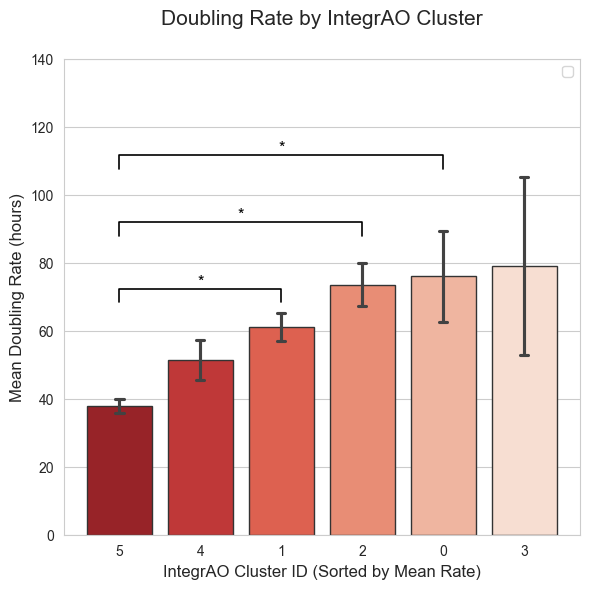

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Ensure cluster labels are in the dataframe
plot_df_clusters = aligned_true_labels.dropna(subset=['doubling_rate']).copy()
plot_df_clusters['integrAO_cluster'] = plot_df_clusters['integrAO_cluster'].astype(str)

# 2. Sort order by doubling rate (as we did before)
cluster_order = (
    plot_df_clusters.groupby('integrAO_cluster')['doubling_rate']
    .mean()
    .sort_values()
    .index
)

# 3. Perform Tukey HSD
tukey = pairwise_tukeyhsd(endog=plot_df_clusters['doubling_rate'],
                          groups=plot_df_clusters['integrAO_cluster'],
                          alpha=0.05)
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# 4. Setup Plot
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")
ax = sns.barplot(
    data=plot_df_clusters, x='integrAO_cluster', y='doubling_rate', 
    order=cluster_order, palette='Reds_r', capsize=.1, edgecolor='0.2', errorbar='se'
)

# 5. Stacking Logic for Brackets
pos_map = {name: i for i, name in enumerate(cluster_order)}
y_max = plot_df_clusters['doubling_rate'].max()
base_y = y_max * 1.05
step = y_max * 0.08  # Distance between stacked brackets

# Filter for significant pairs and sort them by the "distance" between clusters
# This makes the shorter brackets stay lower and longer brackets stay higher
sig_pairs = tukey_df[tukey_df['reject'] == True].copy()
sig_pairs['dist'] = sig_pairs.apply(lambda r: abs(pos_map[str(r['group1'])] - pos_map[str(r['group2'])]), axis=1)
sig_pairs = sig_pairs.sort_values('dist')

# 6. Draw Brackets
for i, (_, row) in enumerate(sig_pairs.iterrows()):
    x1 = pos_map[str(row['group1'])]
    x2 = pos_map[str(row['group2'])]
    
    # Calculate vertical position for this specific bracket
    y = base_y + (i * step)
    
    # Draw bracket line
    plt.plot([x1, x1, x2, x2], [y-190, y + (step*0.2)-190, y + (step*0.2)-190, y-190], lw=1.2, c='k')
    
    # Add star
    plt.text((x1 + x2) * 0.5, y + (step*0.2)-190, "*", ha='center', va='bottom', color='k', fontsize=12)

# 7. Formatting
plt.title('Doubling Rate by IntegrAO Cluster', fontsize=15, pad=25)
plt.xlabel('IntegrAO Cluster ID (Sorted by Mean Rate)', fontsize=12)
plt.ylabel('Mean Doubling Rate (hours)', fontsize=12)
plt.ylim(0, 140) # Dynamic Y-limit

# Add a horizontal line for the global mean for comparison
#plt.axhline(plot_df['doubling_rate'].mean(), color='red', linestyle='--', alpha=0.5, label='Global Mean')
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_85727/450805442.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


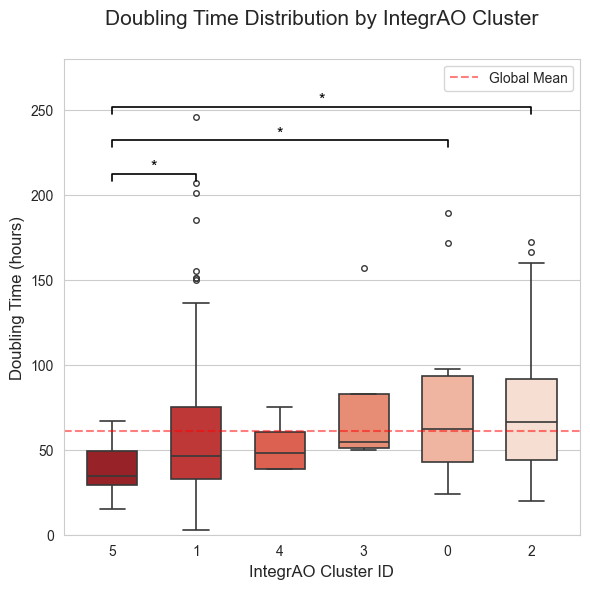

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Ensure cluster labels are in the dataframe
plot_df_clusters = aligned_true_labels.dropna(subset=['doubling_rate']).copy()
plot_df_clusters['integrAO_cluster'] = plot_df_clusters['integrAO_cluster'].astype(str)

# 2. Sort order by doubling rate
cluster_order = (
    plot_df_clusters.groupby('integrAO_cluster')['doubling_rate']
    .median()
    .sort_values()
    .index
)

# 3. Perform Tukey HSD
tukey = pairwise_tukeyhsd(endog=plot_df_clusters['doubling_rate'],
                          groups=plot_df_clusters['integrAO_cluster'],
                          alpha=0.05)
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# 4. Setup Plot
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")

# CHANGED: sns.barplot -> sns.boxplot
# Removed capsize and errorbar
ax = sns.boxplot(
    data=plot_df_clusters, x='integrAO_cluster', y='doubling_rate', 
    order=cluster_order, palette='Reds_r', width=0.6, fliersize=4,
    linewidth=1.2
)

# 5. Stacking Logic for Brackets (Maintained)
pos_map = {name: i for i, name in enumerate(cluster_order)}
y_max = plot_df_clusters['doubling_rate'].max()
base_y = y_max * 1.05
step = y_max * 0.08 

sig_pairs = tukey_df[tukey_df['reject'] == True].copy()
sig_pairs['dist'] = sig_pairs.apply(lambda r: abs(pos_map[str(r['group1'])] - pos_map[str(r['group2'])]), axis=1)
sig_pairs = sig_pairs.sort_values('dist')

# 6. Draw Brackets (Maintained with your specific -190 offset)
for i, (_, row) in enumerate(sig_pairs.iterrows()):
    x1 = pos_map[str(row['group1'])]
    x2 = pos_map[str(row['group2'])]
    
    y = base_y + (i * step)
    
    plt.plot([x1, x1, x2, x2], [y-50, y + (step*0.2)-50, y + (step*0.2)-50, y-50], lw=1.2, c='k')
    plt.text((x1 + x2) * 0.5, y + (step*0.2)-50, "*", ha='center', va='bottom', color='k', fontsize=12)

# 7. Formatting
plt.title('Doubling Time Distribution by IntegrAO Cluster', fontsize=15, pad=25)
plt.xlabel('IntegrAO Cluster ID', fontsize=12)
plt.ylabel('Doubling Time (hours)', fontsize=12)
plt.ylim(0, 280) 

plt.axhline(plot_df_clusters['doubling_rate'].mean(), color='red', linestyle='--', alpha=0.5, label='Global Mean')
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_44330/624705650.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


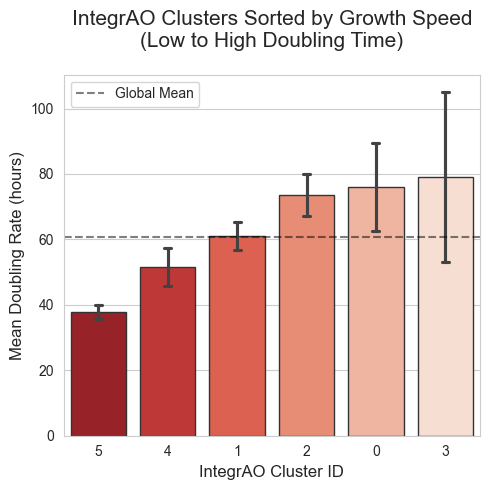

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data
plot_df_clusters = aligned_true_labels.dropna(subset=['doubling_rate']).copy()

# 2. Calculate the mean doubling rate per cluster and sort
# This creates a list of cluster IDs ordered by their average growth speed
sorted_cluster_order = (
    plot_df_clusters.groupby('integrAO_cluster')['doubling_rate']
    .mean()
    .sort_values()
    .index
)

# 3. Initialize the plot
plt.figure(figsize=(5, 5))
sns.set_style("whitegrid")

# 4. Create the sorted barplot
ax = sns.barplot(
    data=plot_df_clusters, 
    x='integrAO_cluster', 
    y='doubling_rate', 
    order=sorted_cluster_order, # The critical line for sorting
    palette='Reds_r',           # Using a reversed Red palette (Darker/Redder = Faster)
    capsize=.1, 
    edgecolor='0.2',
    errorbar='se'
)

# 5. Formatting
plt.title('IntegrAO Clusters Sorted by Growth Speed\n(Low to High Doubling Time)', fontsize=15, pad=20)
plt.xlabel('IntegrAO Cluster ID', fontsize=12)
plt.ylabel('Mean Doubling Rate (hours)', fontsize=12)

# Adding the global mean for baseline comparison
plt.axhline(plot_df_clusters['doubling_rate'].mean(), color='black', linestyle='--', alpha=0.5, label='Global Mean')
plt.legend()

plt.tight_layout()
plt.show()

In [109]:
plot_df_clusters

,primary_tumor_site,doubling_rate,cat,integrAO_cluster
PMLB_organoidID,,,,
BPTO0051.TPO,Breast Cancer,64.000000,2,2
BPTO0064.TXO,Breast Cancer,58.000000,2,3
COMP0037.TXO,Pancreatic Cancer,41.000000,2,1
CSC0073.TXO,Colorectal Cancer,29.000000,2,5
CSC0240.TPO,Colorectal Cancer,26.000000,2,5
...,...,...,...,...
SCLC4874.TXO,Lung Cancer,171.751553,2,0
SGPC0023.TXO,Pancreatic Cancer,27.000000,2,1
SGPC0031.TXO,Pancreatic Cancer,30.000000,2,1


In [87]:
point_sizes

PMLB_organoidID
BPTO0051.TPO    448.00
BPTO0064.TXO    406.00
BPTO0093.TPO      0.01
BPTO0095.TPO      0.01
BPTO0143.TXO      0.01
                 ...  
SGPC0007.TXO      0.01
SGPC0023.TXO    189.00
SGPC0031.TXO    210.00
SGPC0035.TXO    240.52
SGPC0058.TXO    798.00
Name: doubling_rate, Length: 268, dtype: float64

In [60]:
len(true_labels)


268

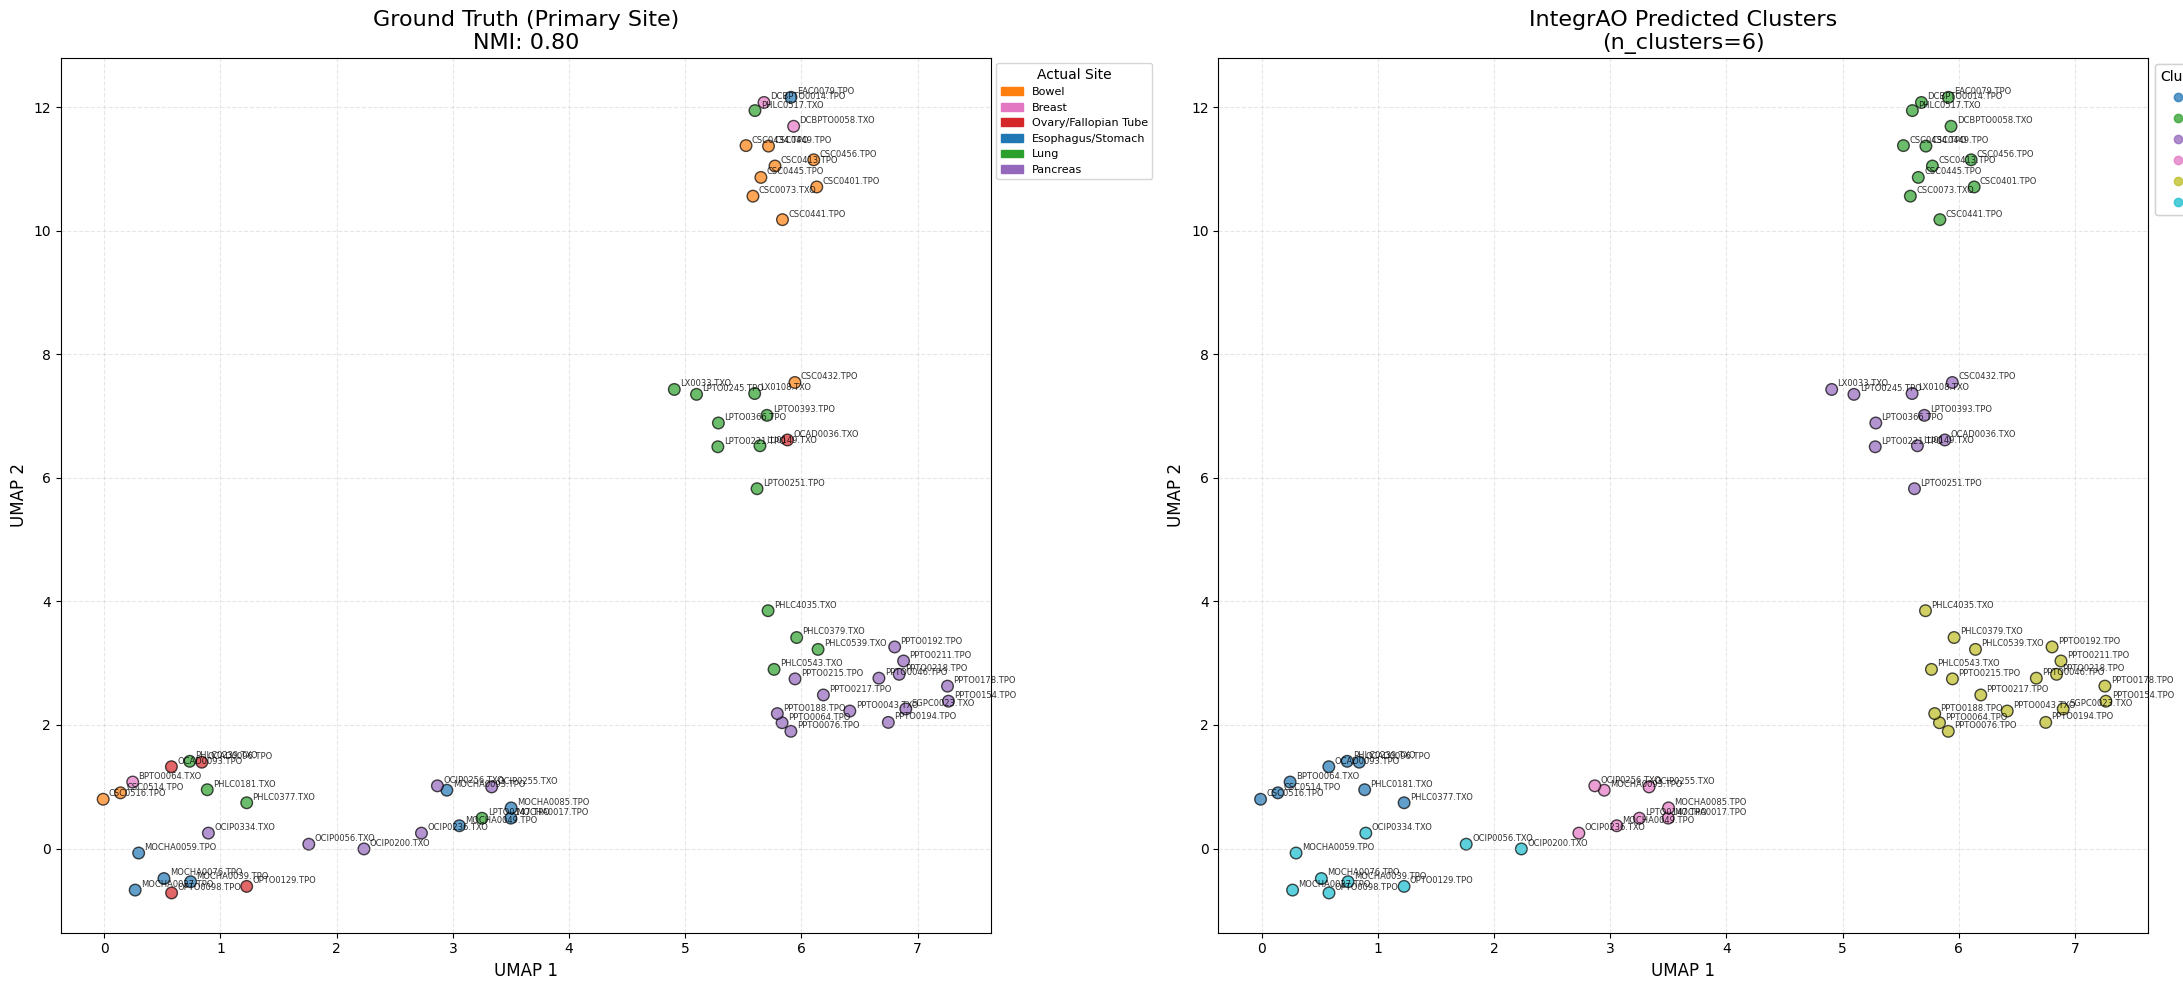

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Prepare and Sort Data
# We sort the dataframe by ID
truelabel_sorted = truelabel.sort_values('PMLB_organoidID')

# CRITICAL STEP: Re-order the embedding and cluster labels 
# to match the new sorted index of the dataframe.
sorted_indices = truelabel_sorted.index
embedding_sorted = embedding[sorted_indices]
labels_sorted = labels[sorted_indices] # Predicted clusters

# Extract sorted lists for plotting
PMLB_organoidID = truelabel_sorted['PMLB_organoidID'].tolist()
true_labels_list = truelabel_sorted['primary_tumor_site'].tolist()

# 2. Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# --- Plot 1: Ground Truth (Corrected Alignment) ---
point_colors_true = [my_cancer_colors[site] for site in true_labels_list]
ax1.scatter(embedding_sorted[:, 0], embedding_sorted[:, 1], 
            c=point_colors_true, s=70, edgecolor='black', alpha=0.7)
ax1.set_title(f"Ground Truth (Primary Site)\nNMI: {score_all:.2f}", fontsize=16)

# --- Plot 2: IntegrAO Predicted Clusters (Corrected Alignment) ---
scatter2 = ax2.scatter(embedding_sorted[:, 0], embedding_sorted[:, 1], 
                       c=labels_sorted, cmap='tab10', s=70, edgecolor='black', alpha=0.7)
ax2.set_title(f"IntegrAO Predicted Clusters\n(n_clusters={cluster_number})", fontsize=16)

# --- Add IDs to every point on both plots ---
for i, ID in enumerate(PMLB_organoidID):
    # Offset text slightly from the dot
    ax1.text(embedding_sorted[i, 0] + 0.05, embedding_sorted[i, 1] + 0.05, 
             str(ID), fontsize=6, alpha=0.8)
    ax2.text(embedding_sorted[i, 0] + 0.05, embedding_sorted[i, 1] + 0.05, 
             str(ID), fontsize=6, alpha=0.8)

# 3. Legends and Cleanup
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in my_cancer_colors.items()]
ax1.legend(handles=legend_patches, title="Actual Site", loc='upper left', 
           bbox_to_anchor=(1, 1), fontsize=8)

legend2 = ax2.legend(*scatter2.legend_elements(), title="Clusters", 
                     loc="upper left", bbox_to_anchor=(1, 1))
ax2.add_artist(legend2)

for ax in [ax1, ax2]:
    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

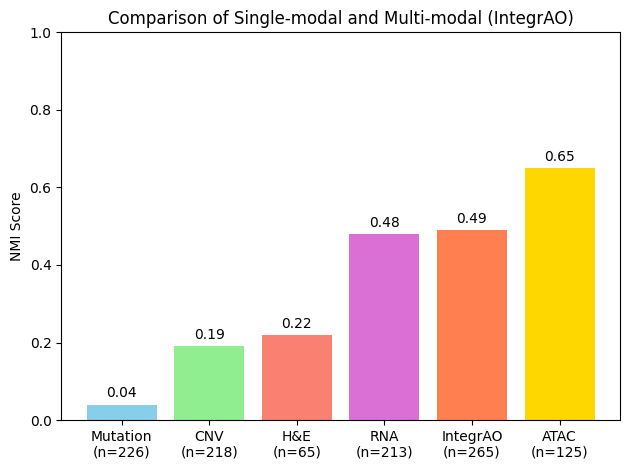

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Data provided
data = {
    'Category': ['H&E\n(n=65)', 'Mutation\n(n=226)', 'CNV\n(n=218)', 'RNA\n(n=213)', 'ATAC\n(n=125)', 'IntegrAO\n(n=265)'],
    'Value': [0.22, 0.04, 0.19, 0.48, 0.65, 0.49]
}

df = pd.DataFrame(data)

# Sort data for the bar plot
df = df.sort_values(by='Value')

# Create the updated bar plot
# We assign the plot to a variable 'bars' to reference it for labeling
bars = plt.bar(df['Category'], df['Value'], color=['skyblue', 'lightgreen', 'salmon', 'orchid','coral', 'gold'])

# Set y-axis label and remove title/x-axis label
plt.ylabel('NMI Score')
plt.xlabel('') 
plt.title('Comparison of Single-modal and Multi-modal (IntegrAO)')

# Formatting adjustments
plt.ylim(0, 1.0)
#plt.xticks(rotation=45, ha='right')

# --- Add values on top of the bars ---
# The padding argument moves the text slightly above the bar
plt.bar_label(bars, padding=3, fmt='%.2f')

plt.tight_layout()

# Save the updated plot
plt.savefig('updated_barplot.png')
plt.show()